# Global Flag Carrier Connectivity Analysis

This project analyses the route networks of major global flag carriers using Python and the OpenFlights dataset.

The analysis focuses on:
- Route network size
- Airline hub concentration
- International connectivity
- Geographic reach

Modules:
- Python
- Pandas
- Matplotlib
- Seaborn

## Importing Libraries and Loading Data

The datasets contain:
- Airlines
- Airports
- Aircraft types
- Route-level flight connections

These datasets are loaded into pandas DataFrames for cleaning and analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_path = os.path.expanduser(
    "~/Desktop/Aviation Flag Carrier Analysis/Data"
)

visuals_path = os.path.expanduser(
    "~/Desktop/Aviation Flag Carrier Analysis/Visuals"
)

airlines = pd.read_csv(f"{file_path}/airlines.csv")
airports = pd.read_csv(f"{file_path}/airports.csv")
routes = pd.read_csv(f"{file_path}/routes.csv")
airplanes = pd.read_csv(f"{file_path}/airplanes.csv")

print("Airlines:", airlines.shape)
print("Airports:", airports.shape)
print("Routes:", routes.shape)
print("Airplanes:", airplanes.shape)

Airlines: (6162, 8)
Airports: (7698, 14)
Routes: (67663, 9)
Airplanes: (246, 3)


## Data Cleaning and Preparation

The code in the cell below:
- Renames dataset columns
- Extracts/Filters major flag carriers
- Removes duplicates
- Standardises airline identifiers for merging

In [2]:
airlines.columns = ["Airline_ID", "Name", "Alias", "IATA", "ICAO", "Callsign", "Country", "Active"]

airports.columns = ["Airport_ID", "Name", "City", "Country", "IATA", "ICAO", "Latitude", "Longitude", "Altitude", "Timezone", "DST", "Tz_Database_Timezone", "Type", "Source"]

routes.columns = ["Airline", "Airline_ID", "Source_Airport", "Source_Airport_ID", "Destination_Airport", "Destination_Airport_ID", "Codeshare", "Stops", "Equipment"]

airplanes.columns = ["Name", "IATA_Code", "ICAO_Code"]

airlines.head()

,Airline_ID,Name,Alias,IATA,ICAO,Callsign,Country,Active
0,-1,Unknown,\N,-,NaN,\N,\N,Y
1,1,Private flight,\N,-,NaN,NaN,NaN,Y
2,2,135 Airways,\N,NaN,GNL,GENERAL,United States,N
3,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
4,4,2 Sqn No 1 Elementary Flying Training School,\N,NaN,WYT,NaN,United Kingdom,N


In [3]:
routes.head() #Route Network Analysis
              #Compares the number of routes operated by each major flag carrier to evaluate relative network size and operational scale

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


In [4]:
#List of 37 major international airlines/ flag carriers
flag_carriers = sorted([
    "Aegean Airlines",
    "Aer Lingus",
    "Air Canada",
    "Air China",
    "Air France",
    "Air New Zealand",
    "All Nippon Airways",
    "American Airlines",
    "Austrian Airlines",
    "British Airways",
    "Brussels Airlines",
    "Cathay Pacific",
    "China Airlines",
    "Egyptair",
    "Emirates",
    "Ethiopian Airlines",
    "Etihad Airways",
    "Finnair",
    "Garuda Indonesia",
    "Iberia Airlines",
    "Japan Airlines",
    "KLM Royal Dutch Airlines",
    "Korean Air",
    "Lufthansa",
    "Malaysia Airlines",
    "Oman Air",
    "Qantas",
    "Qatar Airways",
    "Royal Jordanian",
    "Scandinavian Airlines System",
    "Saudi Arabian Airlines",
    "Singapore Airlines",
    "Swiss International Air Lines",
    "Thai Airways International",
    "Turkish Airlines",
    "United Airlines"
])

In [5]:
#Output is a table with the names of each flag carrier/carriers (one country might have more than one flag carrier)
#Names of each airline with the country which they are based in and their IATA code
major_airlines = airlines[
    airlines["Name"].isin(flag_carriers)
]

major_airlines[["Name", "Country", "IATA"]].sort_values("Name")

,Name,Country,IATA
96,Aegean Airlines,Greece,A3
837,Aer Lingus,Ireland,EI
330,Air Canada,Canada,AC
751,Air China,China,CA
137,Air France,France,AF
345,Air New Zealand,New Zealand,NZ
324,All Nippon Airways,Japan,NH
24,American Airlines,United States,AA
491,Austrian Airlines,Austria,OS
1354,British Airways,United Kingdom,BA


In [6]:
#this removes duplicate airline names (the same airline appearing twice e.g. British Airways) and keep rows with valid IATA codes
major_airlines_clean = (
    major_airlines
    .dropna(subset=["IATA"])
    .drop_duplicates(subset=["Name"], keep="first")
    .sort_values("Name")
)

major_airlines_clean[["Name", "Country", "IATA"]]

,Name,Country,IATA
96,Aegean Airlines,Greece,A3
837,Aer Lingus,Ireland,EI
330,Air Canada,Canada,AC
751,Air China,China,CA
137,Air France,France,AF
345,Air New Zealand,New Zealand,NZ
324,All Nippon Airways,Japan,NH
24,American Airlines,United States,AA
491,Austrian Airlines,Austria,OS
1354,British Airways,United Kingdom,BA


In [7]:
#Standardising Airline IDs. `Airline_ID` column was stored as different data types across datasets 
#(text in one dataset and numeric values in another)
#to ensure accurate merging between airline and route datasets, 
#IDs were converted into numeric format using `pd.to_numeric()`.

routes["Airline_ID"] = pd.to_numeric(routes["Airline_ID"], errors="coerce")
airlines["Airline_ID"] = pd.to_numeric(airlines["Airline_ID"], errors="coerce")
major_airlines_clean["Airline_ID"] = pd.to_numeric(
    major_airlines_clean["Airline_ID"], 
    errors="coerce"
)

In [8]:
#This code produces a table of all 36 selected carriers with their corresponding number of routes
merged_routes = routes.merge(
    major_airlines_clean[["Airline_ID", "Name", "Country"]],
    on="Airline_ID",
    how="inner"
)

route_counts = (
    merged_routes["Name"]
    .value_counts()
    .reset_index()
)

route_counts.columns = ["Airline", "Number_of_Routes"]
route_counts = route_counts.sort_values("Airline")

route_counts

,Airline,Number_of_Routes
27,Aegean Airlines,222
26,Aer Lingus,226
7,Air Canada,705
2,Air China,1260
3,Air France,1071
24,Air New Zealand,233
10,All Nippon Airways,547
0,American Airlines,2354
23,Austrian Airlines,240
9,British Airways,549


The following sections of code produce bar charts for data visualisation

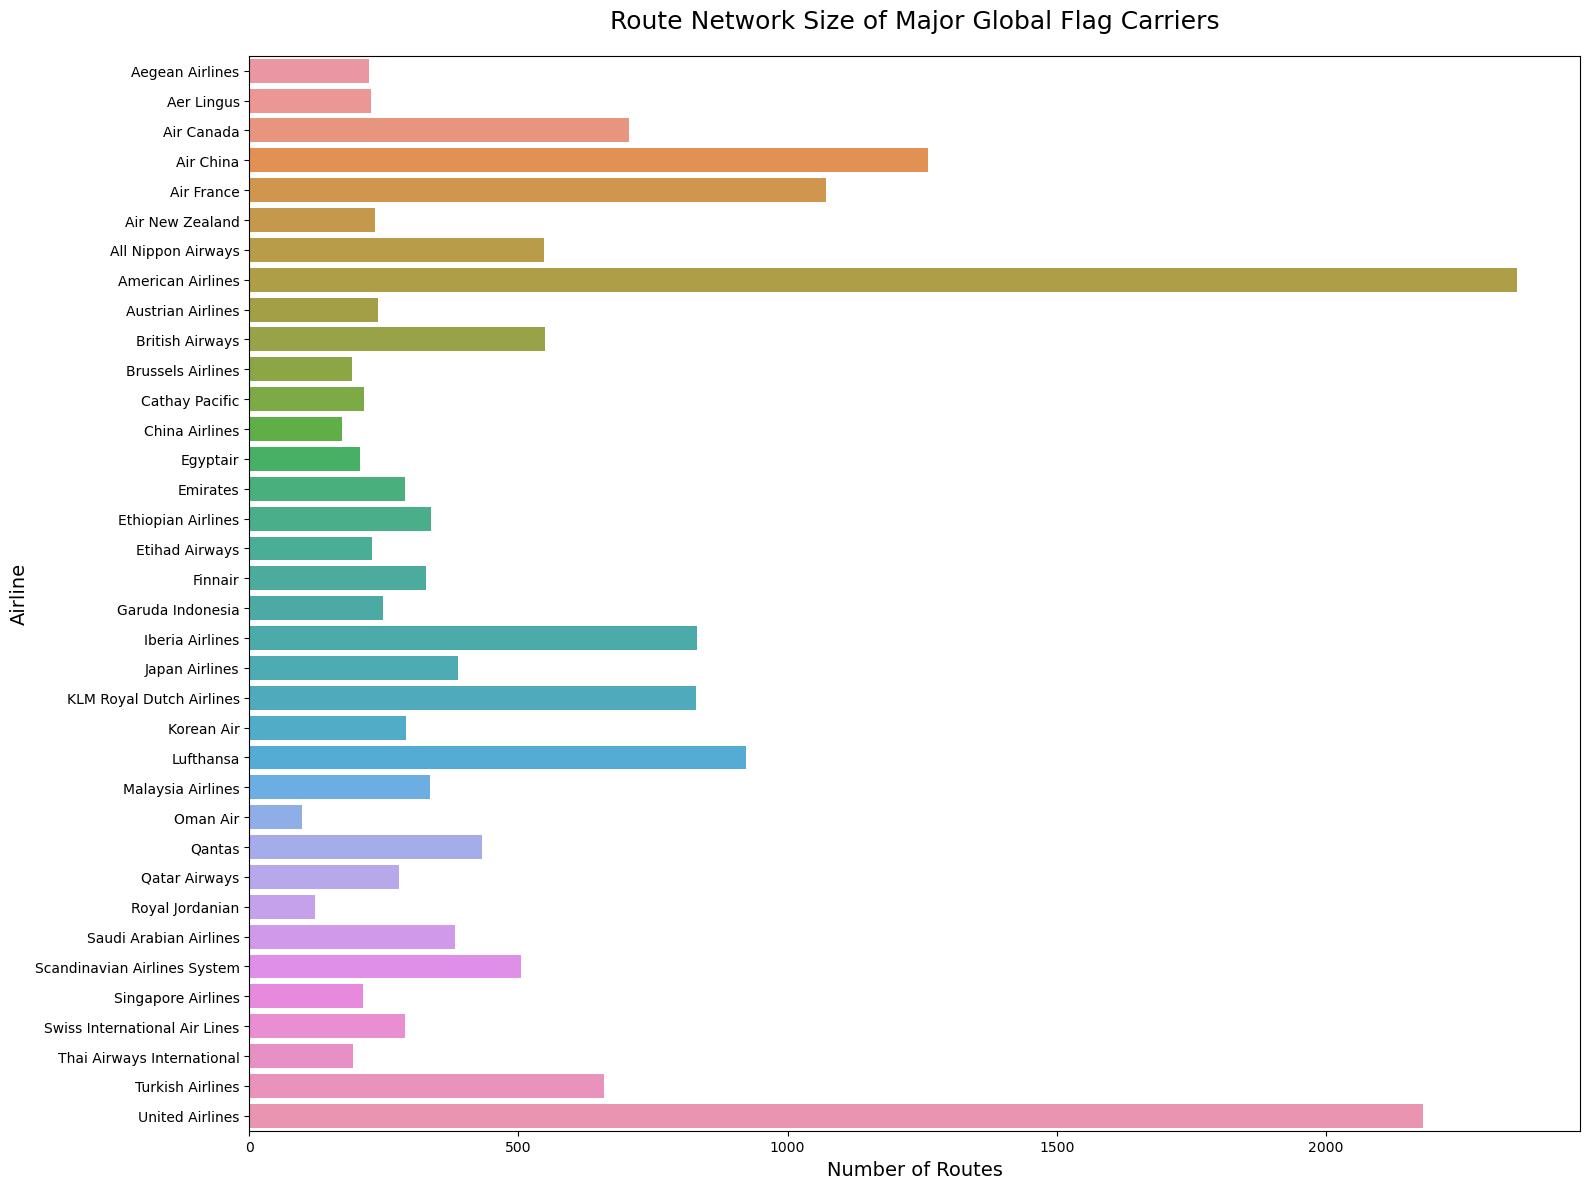

In [9]:
plt.figure(figsize=(16,12))

sns.barplot(
    data=route_counts,
    x="Number_of_Routes",
    y="Airline"
)

plt.title(
    "Route Network Size of Major Global Flag Carriers",
    fontsize=18,
    pad=20
)

plt.xlabel("Number of Routes", fontsize=14)
plt.ylabel("Airline", fontsize=14)

plt.tight_layout()

plt.savefig(
    f"{visuals_path}/route_network_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
hub_counts = (
    merged_routes.groupby(
        ["Name", "Source_Airport"]
    )
    .size()
    .reset_index(name="Routes")
)

hub_counts = (
    hub_counts.sort_values(
        ["Name", "Routes"],
        ascending=[True, False]
    )
)

top_hubs = (
    hub_counts.groupby("Name")
    .head(1)
)

top_hubs

,Name,Source_Airport,Routes
2,Aegean Airlines,ATH,65
106,Aer Lingus,DUB,76
345,Air Canada,YYZ,116
477,Air China,PEK,144
603,Air France,CDG,164
920,Air New Zealand,AKL,39
1024,All Nippon Airways,HND,60
1211,American Airlines,DFW,183
1637,Austrian Airlines,VIE,108
1756,British Airways,LHR,130


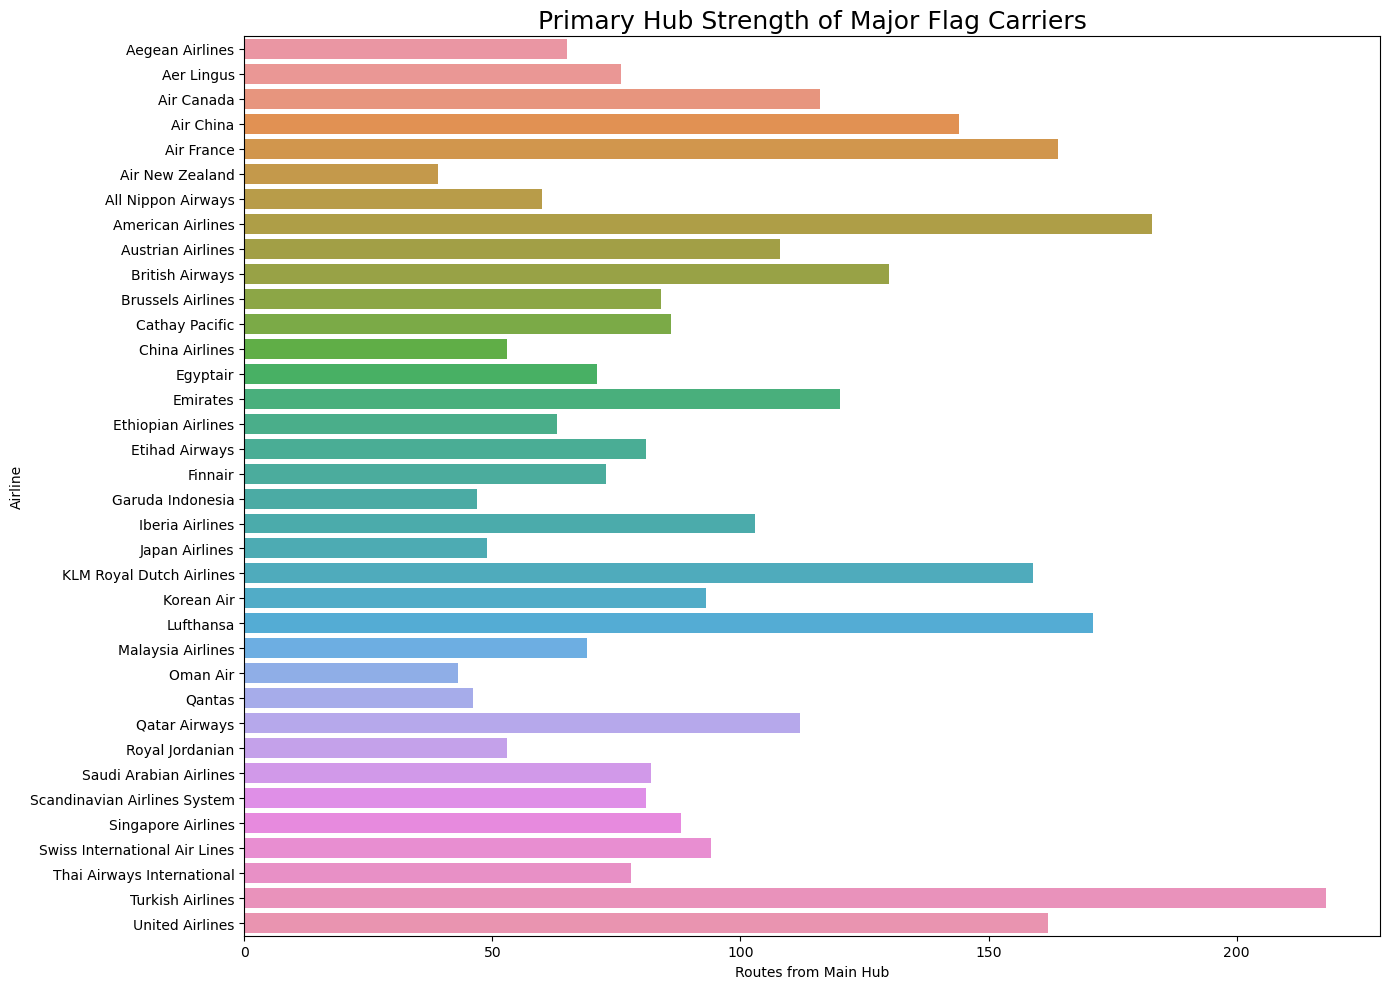

In [11]:
plt.figure(figsize=(14,10))

sns.barplot(
    data=top_hubs,
    x="Routes",
    y="Name"
)

plt.title(
    "Primary Hub Strength of Major Flag Carriers",
    fontsize=18
)

plt.xlabel("Routes from Main Hub")
plt.ylabel("Airline")

plt.tight_layout()

plt.savefig(
    f"{visuals_path}/hub_strength.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
airport_countries = airports[
    ["IATA", "Country"]
].rename(
    columns={
        "IATA": "Destination_Airport",
        "Country": "Destination_Country"
    }
)

routes_with_countries = merged_routes.merge(
    airport_countries,
    on="Destination_Airport",
    how="left"
)

routes_with_countries.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment,Name,Country,Destination_Country
0,A3,96.0,AOK,1459,ATH,3941,NaN,0,DH4,Aegean Airlines,Greece,Greece
1,A3,96.0,AOK,1459,KSJ,1461,NaN,0,DH8,Aegean Airlines,Greece,Greece
2,A3,96.0,AOK,1459,RHO,1472,NaN,0,DH8,Aegean Airlines,Greece,Greece
3,A3,96.0,ARN,737,KLX,1456,NaN,0,319,Aegean Airlines,Greece,Greece
4,A3,96.0,ARN,737,SKG,1486,Y,0,736,Aegean Airlines,Greece,Greece


In [13]:
country_counts = (
    routes_with_countries.groupby("Name")
    ["Destination_Country"]
    .nunique()
    .reset_index()
)

country_counts.columns = [
    "Airline",
    "Countries_Served"
]

country_counts = country_counts.sort_values(
    "Countries_Served",
    ascending=False
)

country_counts

,Airline,Countries_Served
4,Air France,121
34,Turkish Airlines,109
35,United Airlines,96
21,KLM Royal Dutch Airlines,96
7,American Airlines,96
23,Lufthansa,95
9,British Airways,90
15,Ethiopian Airlines,75
14,Emirates,74
27,Qatar Airways,70


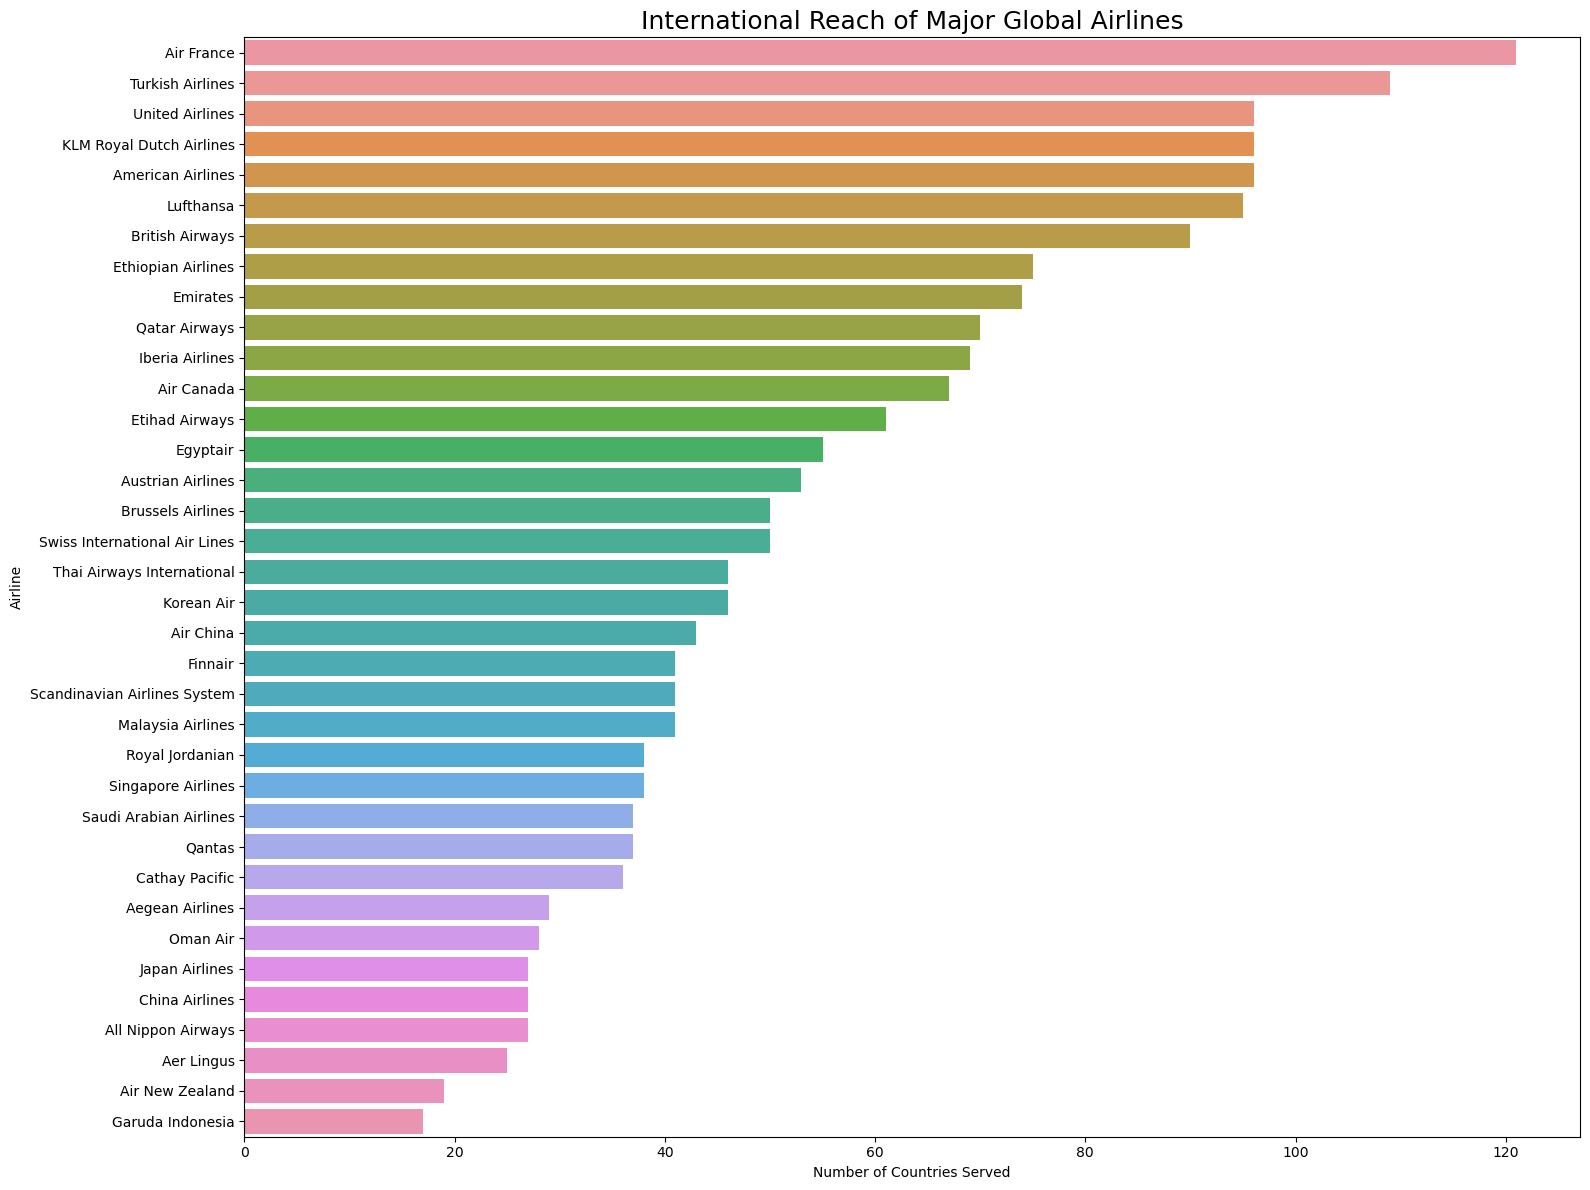

In [14]:
plt.figure(figsize=(16,12))

sns.barplot(
    data=country_counts,
    x="Countries_Served",
    y="Airline"
)

plt.title(
    "International Reach of Major Global Airlines",
    fontsize=18
)

plt.xlabel("Number of Countries Served")
plt.ylabel("Airline")

plt.tight_layout()

plt.savefig(
    f"{visuals_path}/international_reach.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretation of Results

## Route Network Size Analysis

- United Airlines and American Airlines operate the largest route networks among the analysed carriers, reflecting the scale of the United States domestic aviation market.

- Lufthansa, Air China, KLM Royal Dutch Airlines, and Iberia Airlines also demonstrate extensive route networks, highlighting the importance of Europe and East Asia as major global aviation regions.

- Middle Eastern carriers such as Emirates, Qatar Airways, and Etihad Airways operate comparatively smaller route networks but maintain strong international influence through strategically positioned hub airports.

- Smaller flag carriers including Aegean Airlines, Aer Lingus, Oman Air, and Royal Jordanian maintain more limited route networks due to smaller domestic markets and regional operating strategies.

- Scandinavian Airlines System (SAS) and Saudi Arabian Airlines maintain moderate route networks, balancing domestic and international connectivity across regional markets.

- The variation in route network size demonstrates the significant differences in airline business models, geographic constraints, and market demand across regions.

---

## Hub Strength Analysis

- Turkish Airlines demonstrates the strongest hub concentration among the analysed airlines, reflecting Istanbul’s strategic geographic position connecting Europe, Asia, and the Middle East.

- American Airlines and United Airlines also show extremely strong hub dominance, consistent with the hub-and-spoke operating model widely used in the United States aviation market.

- Lufthansa, Air France, KLM Royal Dutch Airlines, and Air China maintain highly concentrated hub operations centred around Frankfurt, Paris Charles de Gaulle, Amsterdam Schiphol, and Beijing respectively.

- Gulf carriers such as Emirates and Qatar Airways rely heavily on centralised mega-hub operations in Dubai and Doha to facilitate global transit connectivity.

- Smaller carriers including Air New Zealand, Garuda Indonesia, and Oman Air exhibit weaker hub concentration due to smaller route networks and lower operational scale.

- European flag carriers generally demonstrate highly centralised route structures compared with airlines operating in geographically larger countries such as the United States.

- Hub concentration appears strongly linked to airline strategy, with transit-focused carriers relying more heavily on single-airport dominance.

---

## International Reach Analysis

- Air France demonstrates the broadest international reach among the analysed airlines, serving the highest number of destination countries.

- Turkish Airlines also exhibits exceptionally strong international diversification, supporting its reputation as one of the world’s most globally connected airlines.

- United Airlines, American Airlines, Lufthansa, and KLM Royal Dutch Airlines maintain extensive international footprints due to large alliance networks and strong long-haul operations.

- Middle Eastern carriers including Emirates, Qatar Airways, and Etihad Airways maintain disproportionately large international reach relative to their route network size, demonstrating highly internationalised operating strategies.

- Ethiopian Airlines stands out as one of Africa’s most internationally connected carriers, serving a broad range of destinations across multiple continents.

- East Asian carriers such as Korean Air, Air China, All Nippon Airways, and Japan Airlines demonstrate strong regional connectivity but comparatively lower international diversification than major European carriers.

- Smaller regional airlines including Garuda Indonesia, Air New Zealand, and Aer Lingus serve fewer countries, reflecting more geographically concentrated operations.

- The analysis highlights how some airlines prioritise route volume while others prioritise geographic diversification and global reach.

---

## Overall Findings

- Airlines based in large domestic markets tend to operate the largest route networks.

- European and Middle Eastern carriers demonstrate particularly strong international connectivity due to their geographic positioning between continents.

- Hub-and-spoke systems remain a dominant operational strategy for major global airlines.

- Geographic location significantly influences airline network strategy and international reach.

- Airlines with smaller route networks can still maintain substantial global influence through efficient hub operations and international route concentration.

- Vviation network structures differ significantly across regions, reflecting variations in market size, geography, regulation, and airline strategy.